# VAE Training and Evaluation Notebook

This notebook trains the convolutional VAE baseline on the processed WM-811K split and evaluates it with the same anomaly-detection protocol used for the autoencoder.

Workflow:
- load `configs/training/train_vae.toml`
- train on normal wafers only
- save checkpoints and history under the configured artifact directory
- derive a threshold from validation-normal scores
- evaluate on the test split with shared metrics


In [7]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.evaluation.reconstruction_metrics import summarize_threshold_metrics, sweep_threshold_metrics
from wafer_defect.models.vae import ConvVariationalAutoencoder, VAEOutput
from wafer_defect.scoring import vae_anomaly_score
from wafer_defect.training.vae import run_vae_epoch

In [8]:
config_path = REPO_ROOT / "configs" / "training" / "train_vae.toml"
config = load_toml(config_path)

# Optional quick smoke-run override:
# config["data"]["metadata_csv"] = "data/processed/x64/wm811k/metadata_dev.csv"
# config["training"]["epochs"] = 3
# config["run"]["output_dir"] = "artifacts/x64/vae_dev"

display(config)

{'run': {'output_dir': 'artifacts/x64/vae_baseline', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 30,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'vae', 'latent_dim': 128, 'beta': 0.005}}

In [9]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)


def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)

In [10]:
set_seed(int(config["run"]["seed"]))
device = resolve_device(config["training"]["device"])
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

image_size = int(config["data"].get("image_size", 64))
beta = float(config["model"].get("beta", 0.01))

train_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="train", image_size=image_size)
val_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="val", image_size=image_size)
test_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="test", image_size=image_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=True,
    num_workers=int(config["data"]["num_workers"]),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)

model = ConvVariationalAutoencoder(
    latent_dim=int(config["model"]["latent_dim"]),
    image_size=image_size,
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(config["training"]["learning_rate"]),
    weight_decay=float(config["training"]["weight_decay"]),
)

patience = int(config["training"].get("early_stopping_patience", 0))
min_delta = float(config["training"].get("early_stopping_min_delta", 0.0))
checkpoint_every = int(config["training"].get("checkpoint_every", 5))

print(f"""
Device: {device}
Output dir: {output_dir}
Beta: {beta}

Train samples: {len(train_dataset)}
Val samples: {len(val_dataset)}
Test samples: {len(test_dataset)}
""")


Device: cuda
Output dir: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\vae_baseline
Beta: 0.005

Train samples: 40000
Val samples: 5000
Test samples: 5250



In [11]:
print(model)

ConvVariationalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ReLU()
    (1): Unflatten(dim=1, unflattened_size=(64, 8, 8))
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [12]:
import subprocess


def format_toml_value(value):
    if isinstance(value, bool):
        return "true" if value else "false"
    if isinstance(value, (int, float)):
        return repr(value)
    escaped = str(value).replace("\\", "\\\\").replace('"', '\\"')
    return f'"{escaped}"'


def dump_toml(config_dict):
    lines = []
    for section, values in config_dict.items():
        lines.append(f"[{section}]")
        for key, value in values.items():
            lines.append(f"{key} = {format_toml_value(value)}")
        lines.append("")
    return "\n".join(lines).rstrip() + "\n"


def beta_tag(beta_value):
    return str(beta_value).replace(".", "p")


def run_logged_command(cmd, cwd, log_path, prefix):
    with log_path.open("w", encoding="utf-8") as handle:
        process = subprocess.Popen(
            cmd,
            cwd=cwd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(f"[{prefix}] {line}", end="")
            handle.write(line)
        return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, cmd)


RUN_BETA_SWEEP = False  # Set to False to skip the sweep and use the single-run training loop below
beta_sweep_betas = [0.001, 0.005, 0.01, 0.05]
beta_sweep_root = REPO_ROOT / "artifacts" / "x64" / "vae_beta_sweep"
beta_sweep_configs_dir = beta_sweep_root / "configs"
beta_sweep_configs_dir.mkdir(parents=True, exist_ok=True)
beta_sweep_log_path = beta_sweep_root / "beta_sweep_log.jsonl"

history = []
history_df = None
training_summary = None
beta_sweep_df = None

if RUN_BETA_SWEEP:
    beta_sweep_results = []
    if beta_sweep_log_path.exists():
        beta_sweep_log_path.unlink()

    print({
        "betas": beta_sweep_betas,
        "sweep_root": str(beta_sweep_root),
        "log_path": str(beta_sweep_log_path),
    })

    for run_index, beta_value in enumerate(beta_sweep_betas, start=1):
        run_config = {section: values.copy() for section, values in config.items()}
        tag = beta_tag(beta_value)
        run_output_dir = beta_sweep_root / f"beta_{tag}"
        run_config["run"]["output_dir"] = run_output_dir.relative_to(REPO_ROOT).as_posix()
        run_config["model"]["beta"] = beta_value

        config_path = beta_sweep_configs_dir / f"train_vae_beta_{tag}.toml"
        config_path.write_text(dump_toml(run_config), encoding="utf-8")

        train_cmd = [
            sys.executable,
            "scripts/train_vae.py",
            "--config",
            str(config_path.relative_to(REPO_ROOT)),
        ]
        eval_cmd = [
            sys.executable,
            "scripts/evaluate_reconstruction_model.py",
            "--checkpoint",
            str((run_output_dir / "best_model.pt").relative_to(REPO_ROOT)),
            "--config",
            str(config_path.relative_to(REPO_ROOT)),
            "--output-dir",
            str((run_output_dir / "evaluation").relative_to(REPO_ROOT)),
        ]

        train_log_path = run_output_dir / "train.log"
        eval_log_path = run_output_dir / "eval.log"
        run_log = {
            "run_index": run_index,
            "total_runs": len(beta_sweep_betas),
            "beta": beta_value,
            "tag": tag,
            "output_dir": str(run_output_dir),
            "config_path": str(config_path),
            "train_cmd": train_cmd,
            "eval_cmd": eval_cmd,
            "train_log_path": str(train_log_path),
            "eval_log_path": str(eval_log_path),
        }

        print(f"[{run_index}/{len(beta_sweep_betas)}] Starting beta={beta_value} -> {run_output_dir}")
        # print({"train_cmd": train_cmd, "eval_cmd": eval_cmd})
        run_output_dir.mkdir(parents=True, exist_ok=True)
        # run_logged_command(train_cmd, REPO_ROOT, train_log_path, prefix=f"beta={beta_value} train")
        print(f"[{run_index}/{len(beta_sweep_betas)}] Training complete for beta={beta_value}")
        # run_logged_command(eval_cmd, REPO_ROOT, eval_log_path, prefix=f"beta={beta_value} eval")
        print(f"[{run_index}/{len(beta_sweep_betas)}] Evaluation complete for beta={beta_value}")

        summary = json.loads((run_output_dir / "evaluation" / "summary.json").read_text(encoding="utf-8"))
        metrics = summary["metrics_at_validation_threshold"]
        best_sweep = summary["best_threshold_sweep"]
        result_row = {
            "beta": beta_value,
            "threshold": metrics["threshold"],
            "val_threshold_precision": metrics["precision"],
            "val_threshold_recall": metrics["recall"],
            "val_threshold_f1": metrics["f1"],
            "auroc": metrics["auroc"],
            "auprc": metrics["auprc"],
            "best_sweep_threshold": best_sweep["threshold"],
            "best_sweep_precision": best_sweep["precision"],
            "best_sweep_recall": best_sweep["recall"],
            "best_sweep_f1": best_sweep["f1"],
        }
        beta_sweep_results.append(result_row)
        run_log["metrics_at_validation_threshold"] = metrics
        run_log["best_threshold_sweep"] = best_sweep
        with beta_sweep_log_path.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(run_log) + "\n")
        print({
            "beta": beta_value,
            "val_threshold_f1": metrics["f1"],
            "auroc": metrics["auroc"],
            "auprc": metrics["auprc"],
            "best_sweep_f1": best_sweep["f1"],
            "train_log_path": str(train_log_path),
            "eval_log_path": str(eval_log_path),
        })

    beta_sweep_results = sorted(beta_sweep_results, key=lambda row: row["val_threshold_f1"], reverse=True)
    beta_sweep_df = pd.DataFrame(beta_sweep_results)
    summary_path = beta_sweep_root / "beta_sweep_summary.json"
    summary_path.write_text(json.dumps({"betas": beta_sweep_betas, "results": beta_sweep_results}, indent=2), encoding="utf-8")
    print(f"Saved beta sweep summary to {summary_path}")
    print(f"Saved per-run beta sweep log to {beta_sweep_log_path}")
    display(beta_sweep_df)
    print("Beta sweep finished. Set RUN_BETA_SWEEP = False and rerun this cell to use the single-run plots and notebook evaluation cells below.")
else:
    best_val_loss = float("inf")
    best_epoch = 0
    best_state_dict = None
    stale_epochs = 0

    for epoch in range(int(config["training"]["epochs"])):
        train_metrics = run_vae_epoch(model, train_loader, device, beta=beta, optimizer=optimizer)
        val_metrics = run_vae_epoch(model, val_loader, device, beta=beta)

        record = {
            "epoch": epoch + 1,
            "train_loss": train_metrics.loss,
            "train_reconstruction_loss": train_metrics.reconstruction_loss,
            "train_kl_loss": train_metrics.kl_loss,
            "val_loss": val_metrics.loss,
            "val_reconstruction_loss": val_metrics.reconstruction_loss,
            "val_kl_loss": val_metrics.kl_loss,
        }
        history.append(record)
        print(record)

        improved = (best_val_loss - val_metrics.loss) > min_delta
        if improved:
            best_val_loss = val_metrics.loss
            best_epoch = epoch + 1
            best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            stale_epochs = 0
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": best_state_dict,
                    "optimizer_state_dict": optimizer.state_dict(),
                    "config": config,
                    "best_epoch": best_epoch,
                    "best_val_loss": best_val_loss,
                    "stale_epochs": stale_epochs,
                    "history": history,
                },
                output_dir / "best_model.pt",
            )
        else:
            stale_epochs += 1

        latest_checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        }
        torch.save(latest_checkpoint, output_dir / "latest_checkpoint.pt")

        if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
            torch.save(latest_checkpoint, output_dir / f"checkpoint_epoch_{epoch + 1}.pt")

        if patience > 0 and stale_epochs >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}"
            )
            break

    torch.save(
        {
            "epoch": len(history),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        },
        output_dir / "last_model.pt",
    )

    with (output_dir / "history.json").open("w", encoding="utf-8") as handle:
        json.dump(history, handle, indent=2)

    training_summary = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_ran": len(history),
        "beta": beta,
    }
    with (output_dir / "summary.json").open("w", encoding="utf-8") as handle:
        json.dump(training_summary, handle, indent=2)

    history_df = pd.DataFrame(history)
    display(history_df.tail())
    training_summary


{'epoch': 1, 'train_loss': 0.028091077148914338, 'train_reconstruction_loss': 0.027303733146190643, 'train_kl_loss': 0.15746881566201337, 'val_loss': 0.02557742169499397, 'val_reconstruction_loss': 0.02500851172208786, 'val_kl_loss': 0.11378200496435166}
{'epoch': 2, 'train_loss': 0.025579926601052284, 'train_reconstruction_loss': 0.02502680926024914, 'train_kl_loss': 0.1106234802365303, 'val_loss': 0.025443860614299773, 'val_reconstruction_loss': 0.02489943327307701, 'val_kl_loss': 0.1088854885816574}
{'epoch': 3, 'train_loss': 0.025448000660538674, 'train_reconstruction_loss': 0.024962175816297533, 'train_kl_loss': 0.09716497627496719, 'val_loss': 0.025322258514165877, 'val_reconstruction_loss': 0.02490569517314434, 'val_kl_loss': 0.08331267290115356}
{'epoch': 4, 'train_loss': 0.025210330855846404, 'train_reconstruction_loss': 0.024751983085274695, 'train_kl_loss': 0.0916695554614067, 'val_loss': 0.02489037742614746, 'val_reconstruction_loss': 0.024394700995087625, 'val_kl_loss': 0.

,epoch,train_loss,train_reconstruction_loss,train_kl_loss,val_loss,val_reconstruction_loss,val_kl_loss
25,26,0.022065,0.021254,0.162312,0.021911,0.021077,0.166845
26,27,0.022020,0.021203,0.163474,0.021876,0.021013,0.172736
27,28,0.021991,0.021167,0.164642,0.021841,0.021000,0.168212
28,29,0.021946,0.021117,0.165868,0.021817,0.021018,0.159957
29,30,0.021911,0.021076,0.166854,0.021730,0.020894,0.167222


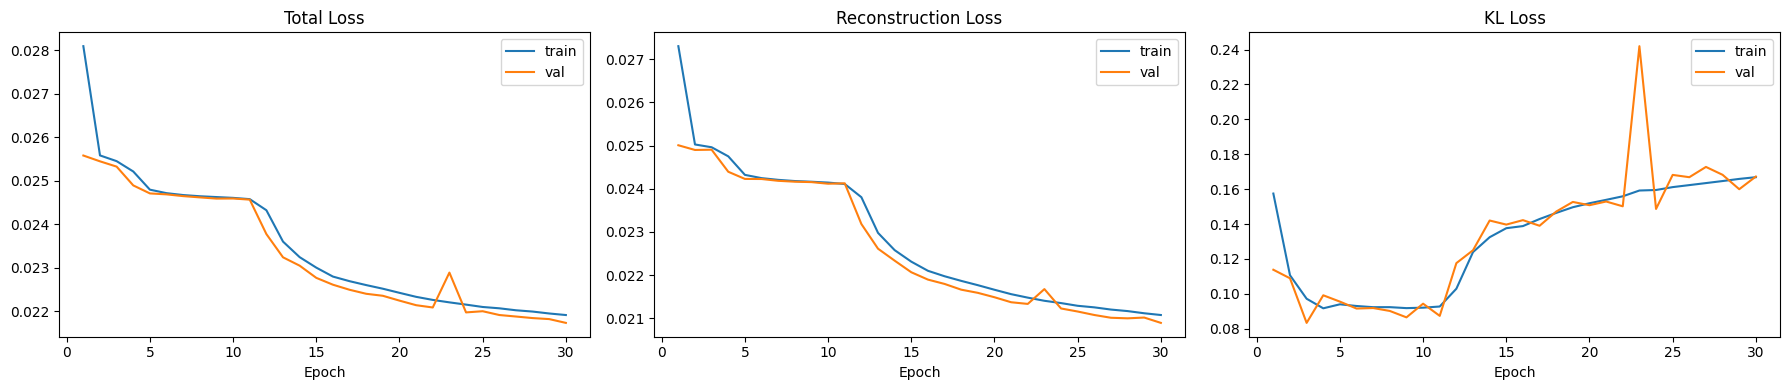

In [13]:
run_beta_sweep = globals().get("RUN_BETA_SWEEP", False)

if run_beta_sweep:
    print("Skip this cell after a beta sweep. Set RUN_BETA_SWEEP = False and rerun the training cell for a single notebook run.")
else:
    history_df = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_reconstruction_loss"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_reconstruction_loss"], label="val")
    axes[1].set_title("Reconstruction Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history_df["epoch"], history_df["train_kl_loss"], label="train")
    axes[2].plot(history_df["epoch"], history_df["val_kl_loss"], label="val")
    axes[2].set_title("KL Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


In [14]:
run_beta_sweep = globals().get("RUN_BETA_SWEEP", False)

if run_beta_sweep:
    print("Skip this cell after a beta sweep. Set RUN_BETA_SWEEP = False and rerun the training cell for a single notebook run.")
else:
    def collect_scores(model: ConvVariationalAutoencoder, dataloader: DataLoader, device: torch.device, beta: float) -> pd.DataFrame:
        rows = []
        model.eval()
        with torch.inference_mode():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                if not isinstance(outputs, VAEOutput):
                    raise TypeError("VAE model must return VAEOutput")

                scores = vae_anomaly_score(
                    inputs,
                    outputs.reconstruction,
                    outputs.mu,
                    outputs.logvar,
                    beta=beta,
                )
                for score, label in zip(scores.cpu().tolist(), labels.tolist()):
                    rows.append({"score": float(score), "is_anomaly": int(label)})

        return pd.DataFrame(rows)


    checkpoint = torch.load(output_dir / "best_model.pt", map_location=device)
    eval_model = ConvVariationalAutoencoder(
        latent_dim=int(config["model"]["latent_dim"]),
        image_size=image_size,
    ).to(device)
    eval_model.load_state_dict(checkpoint["model_state_dict"])

    val_scores_df = collect_scores(eval_model, val_loader, device, beta=beta)
    test_scores_df = collect_scores(eval_model, test_loader, device, beta=beta)

    threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(0.95))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()

    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)

    evaluation_dir = output_dir / "evaluation_notebook"
    evaluation_dir.mkdir(parents=True, exist_ok=True)
    val_scores_df.to_csv(evaluation_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(evaluation_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(evaluation_dir / "threshold_sweep.csv", index=False)

    evaluation_summary = {
        "threshold": threshold,
        "metrics_at_validation_threshold": metrics,
        "best_threshold_sweep": best_sweep,
    }
    with (evaluation_dir / "summary.json").open("w", encoding="utf-8") as handle:
        json.dump(evaluation_summary, handle, indent=2)

    display(pd.DataFrame([metrics]))
    display(pd.DataFrame([best_sweep]))
    evaluation_summary


,threshold,precision,recall,f1,auroc,auprc,predicted_anomalies,confusion_matrix
0,0.034248,0.286104,0.42,0.340357,0.771391,0.372184,367,"[[4738, 262], [145, 105]]"


,threshold,precision,recall,f1,predicted_anomalies
0,0.038787,0.572414,0.332,0.420253,144


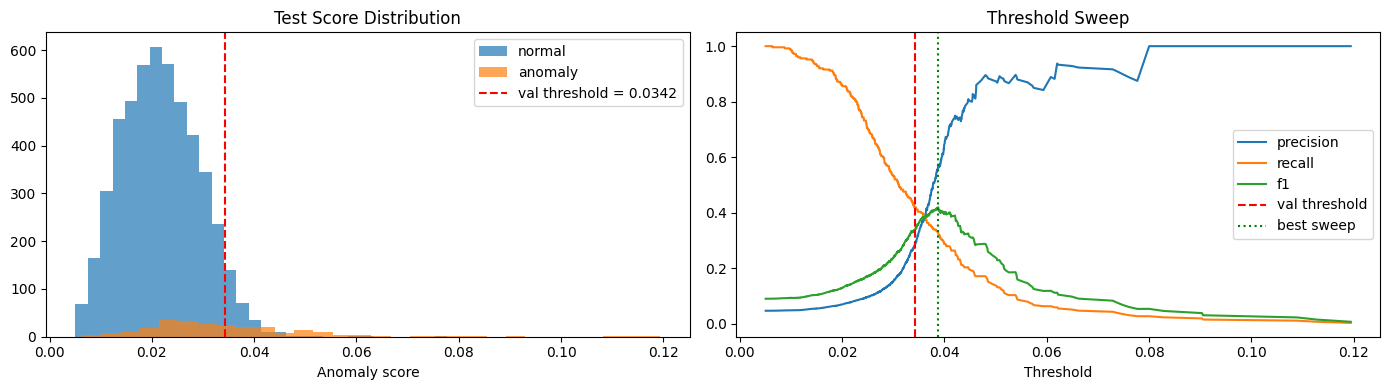

,threshold,precision,recall,f1,predicted_anomalies
5102,0.038787,0.572414,0.332,0.420253,144
5101,0.038769,0.568493,0.332,0.419192,145
5100,0.038764,0.564626,0.332,0.418136,146
5095,0.038538,0.552632,0.336,0.417910,151
5099,0.038763,0.560811,0.332,0.417085,147
5094,0.038503,0.549020,0.336,0.416873,152
5103,0.038806,0.569444,0.328,0.416244,143
5098,0.038632,0.557047,0.332,0.416040,148
5093,0.038477,0.545455,0.336,0.415842,153
5097,0.038611,0.553333,0.332,0.415000,149


In [15]:
run_beta_sweep = globals().get("RUN_BETA_SWEEP", False)

if run_beta_sweep:
    print("Skip this cell after a beta sweep. Set RUN_BETA_SWEEP = False and rerun the training cell for a single notebook run.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(test_scores_df.loc[test_scores_df["is_anomaly"] == 0, "score"], bins=30, alpha=0.7, label="normal")
    axes[0].hist(test_scores_df.loc[test_scores_df["is_anomaly"] == 1, "score"], bins=30, alpha=0.7, label="anomaly")
    axes[0].axvline(threshold, color="red", linestyle="--", label=f"val threshold = {threshold:.4f}")
    axes[0].set_title("Test Score Distribution")
    axes[0].set_xlabel("Anomaly score")
    axes[0].legend()

    axes[1].plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
    axes[1].plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
    axes[1].plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
    axes[1].axvline(threshold, color="red", linestyle="--", label="val threshold")
    axes[1].axvline(best_sweep["threshold"], color="green", linestyle=":", label="best sweep")
    axes[1].set_title("Threshold Sweep")
    axes[1].set_xlabel("Threshold")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    display(threshold_sweep_df.sort_values("f1", ascending=False).head(10))


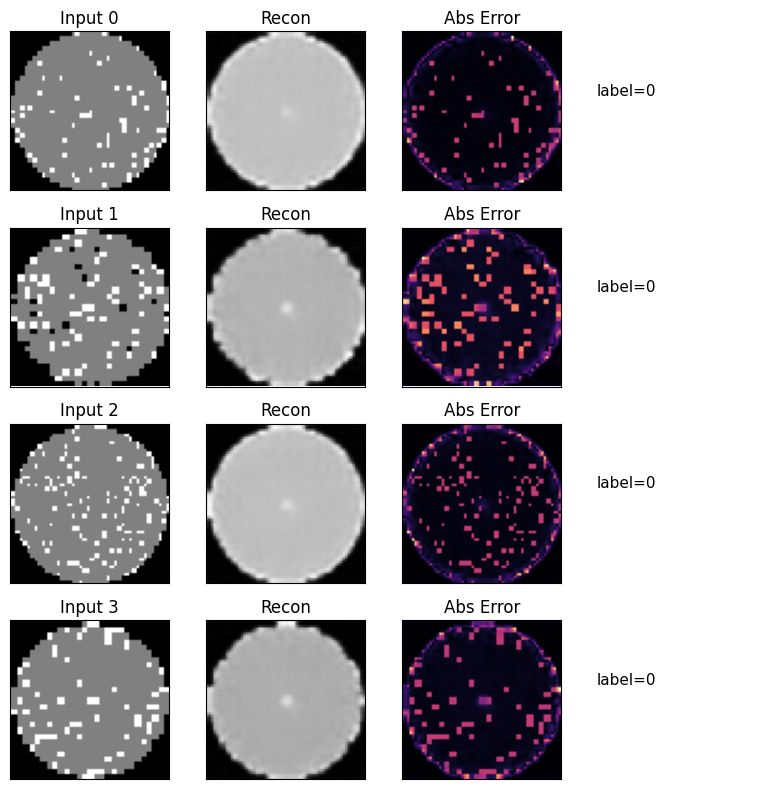

In [17]:
run_beta_sweep = globals().get("RUN_BETA_SWEEP", False)

if run_beta_sweep:
    print("Skip this cell after a beta sweep. Set RUN_BETA_SWEEP = False and rerun the training cell for a single notebook run.")
else:
    sample_inputs, sample_labels = next(iter(test_loader))
    sample_inputs = sample_inputs.to(device)

    with torch.inference_mode():
        sample_outputs = eval_model(sample_inputs)

    recons = sample_outputs.reconstruction.cpu()
    inputs = sample_inputs.cpu()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for row in range(4):
        axes[row, 0].imshow(inputs[row, 0], cmap="gray")
        axes[row, 0].set_title(f"Input {row}")
        axes[row, 1].imshow(recons[row, 0], cmap="gray")
        axes[row, 1].set_title("Recon")
        axes[row, 2].imshow((inputs[row, 0] - recons[row, 0]).abs(), cmap="magma")
        axes[row, 2].set_title("Abs Error")
        axes[row, 3].text(0.05, 0.6, f"label={int(sample_labels[row])}", fontsize=11)
        axes[row, 3].axis("off")

    for ax in axes.ravel():
        if ax.has_data():
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()
